# Weather Data Analysis

In [15]:
import pandas as pd

df = pd.read_csv("weatherHistory.csv")
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


## Dataset Overview

In [16]:
def dataset_overview(data):
    print("Number of Rows:", data.shape[0])
    print("Number of Columns:", data.shape[1])
    print("\nData Types:\n", data.dtypes)
    print("\nFirst 5 Rows:\n", data.head())

dataset_overview(df)

Number of Rows: 96453
Number of Columns: 12

Data Types:
 Formatted Date               object
Summary                      object
Precip Type                  object
Temperature (C)             float64
Apparent Temperature (C)    float64
Humidity                    float64
Wind Speed (km/h)           float64
Wind Bearing (degrees)      float64
Visibility (km)             float64
Loud Cover                  float64
Pressure (millibars)        float64
Daily Summary                object
dtype: object

First 5 Rows:
                   Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   


## Identify Missing Values

In [17]:
def identify_missing_value(data):
    print("\nMissing Values in Dataset:\n")
    print(data.isnull().sum())

identify_missing_value(df)


Missing Values in Dataset:

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64


## Handle Missing Values

In [18]:
def handle_missing_values(data):
    print("\nHandling Missing Values...\n")
    cat = data.select_dtypes(include=['object','category']).columns

    for col in cat:
        if data[col].isnull().sum() > 0:
            mode_value = data[col].mode()
            if len(mode_value) > 0:
                data[col] = data[col].fillna(mode_value[0])

    return data

df = handle_missing_values(df)
df.isnull().sum()


Handling Missing Values...



Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64

## Statistical Summary

This section performs statistical analysis of the numerical features in the dataset.

The following statistics are calculated:
- Mean
- Median
- Mode
- Standard Deviation
- Variance
- Minimum and Maximum
- Range
- Quartiles (Q1, Q2, Q3)
- Skewness
- Kurtosis

These statistics help us understand the distribution, variability, and shape of the data.

In [19]:
def statistical_summary(data):
    numeric_data = data.select_dtypes(include='number')

    summary = pd.DataFrame({
        "Count": numeric_data.count(),
        "Mean": numeric_data.mean(),
        "Median": numeric_data.median(),
        "Mode": numeric_data.mode().iloc[0],
        "Standard Deviation": numeric_data.std(),
        "Variance": numeric_data.var(),
        "Minimum": numeric_data.min(),
        "Maximum": numeric_data.max(),
        "Range": numeric_data.max() - numeric_data.min(),
        "Q1 (25%)": numeric_data.quantile(0.25),
        "Q2 (50%)": numeric_data.quantile(0.50),
        "Q3 (75%)": numeric_data.quantile(0.75),
        "Skewness": numeric_data.skew(),
        "Kurtosis": numeric_data.kurt()
    })

    print(summary)
    return summary

statistical_summary(df)

                          Count         Mean     Median       Mode  \
Temperature (C)           96453    11.932678    12.0000   7.222222   
Apparent Temperature (C)  96453    10.855029    12.0000  12.777778   
Humidity                  96453     0.734899     0.7800   0.930000   
Wind Speed (km/h)         96453    10.810640     9.9659   3.220000   
Wind Bearing (degrees)    96453   187.509232   180.0000   0.000000   
Visibility (km)           96453    10.347325    10.0464   9.982000   
Loud Cover                96453     0.000000     0.0000   0.000000   
Pressure (millibars)      96453  1003.235956  1016.4500   0.000000   

                          Standard Deviation      Variance    Minimum  \
Temperature (C)                     9.551546     91.232037 -21.822222   
Apparent Temperature (C)           10.696847    114.422544 -27.716667   
Humidity                            0.195473      0.038210   0.000000   
Wind Speed (km/h)                   6.913571     47.797464   0.000000   
Wind

,Count,Mean,Median,Mode,Standard Deviation,Variance,Minimum,Maximum,Range,Q1 (25%),Q2 (50%),Q3 (75%),Skewness,Kurtosis
Temperature (C),96453,11.932678,12.0000,7.222222,9.551546,91.232037,-21.822222,39.905556,61.727778,4.688889,12.0000,18.838889,0.094127,-0.566791
Apparent Temperature (C),96453,10.855029,12.0000,12.777778,10.696847,114.422544,-27.716667,39.344444,67.061111,2.311111,12.0000,18.838889,-0.057302,-0.706844
Humidity,96453,0.734899,0.7800,0.930000,0.195473,0.038210,0.000000,1.000000,1.000000,0.600000,0.7800,0.890000,-0.715880,-0.462170
Wind Speed (km/h),96453,10.810640,9.9659,3.220000,6.913571,47.797464,0.000000,63.852600,63.852600,5.828200,9.9659,14.135800,1.113493,1.769284
Wind Bearing (degrees),96453,187.509232,180.0000,0.000000,107.383428,11531.200691,0.000000,359.000000,359.000000,116.000000,180.0000,290.000000,-0.154643,-1.131534
Visibility (km),96453,10.347325,10.0464,9.982000,4.192123,17.573897,0.000000,16.100000,16.100000,8.339800,10.0464,14.812000,-0.498712,-0.260339
Loud Cover,96453,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000
Pressure (millibars),96453,1003.235956,1016.4500,0.000000,116.969906,13681.958835,0.000000,1046.380000,1046.380000,1011.900000,1016.4500,1021.090000,-8.422506,69.268758


## Data Visualization

Data visualization helps in understanding the distribution and relationships between variables in the dataset.

Different types of charts are used to visually explore the weather data, such as:
- Histogram for distribution
- Boxplot for detecting outliers
- Scatter plot for relationships between variables

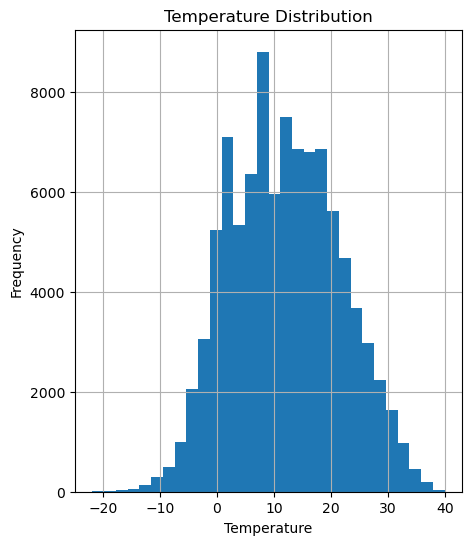

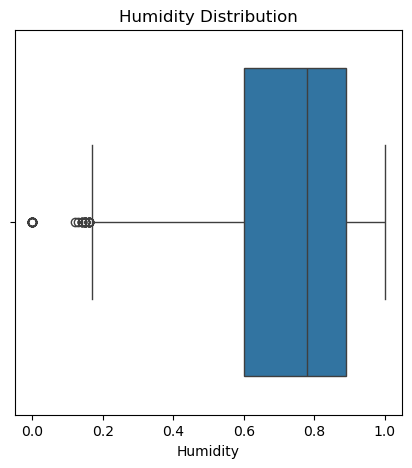

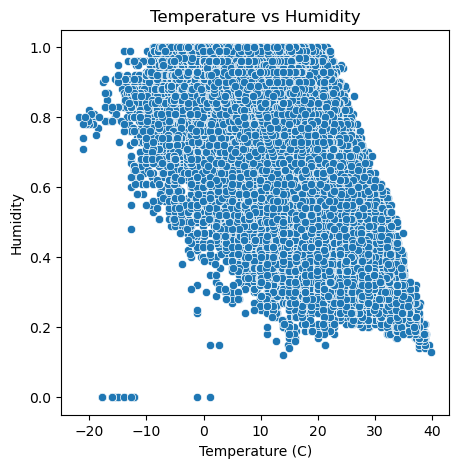

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

def create_visualization(data):

    plt.figure(figsize=(5,6))
    data['Temperature (C)'].hist(bins=30)
    plt.title("Temperature Distribution")
    plt.xlabel("Temperature")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(5,5))
    sns.boxplot(x=data['Humidity'])
    plt.title("Humidity Distribution")
    plt.show()

    plt.figure(figsize=(5,5))
    sns.scatterplot(x='Temperature (C)', y='Humidity', data=data)
    plt.title("Temperature vs Humidity")
    plt.show()

create_visualization(df)

## Temperature and Humidity Trend Analysis

In this section, we analyze how temperature and humidity change over time in the dataset.

Understanding these trends helps us observe weather variations and seasonal patterns.  
Line charts are used to visualize how temperature and humidity fluctuate across different dates.

In [21]:
def temp_humidity_trends(data):
    data['Formatted Date'] = pd.to_datetime(data['Formatted Date'], errors='coerce')
    daily_data = data.groupby(data['Formatted Date'].dt.date).mean(numeric_only=True)

    plt.figure(figsize=(10,5))
    sns.lineplot(x=daily_data.index, y=daily_data['Temperature (C)'])
    plt.title("Temperature Trend Over Time")
    plt.xticks(rotation=45)
    plt.show()

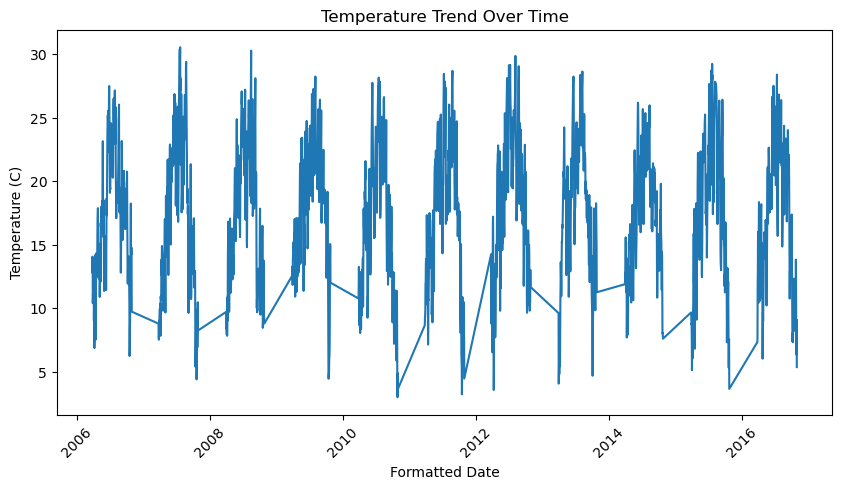

In [23]:
temp_humidity_trends(df)

In [24]:
def humidity_trend(data):
    data['Formatted Date'] = pd.to_datetime(data['Formatted Date'])
    daily_data = data.groupby(data['Formatted Date'].dt.date).mean(numeric_only=True)

    plt.figure(figsize=(10,5))
    sns.lineplot(x=daily_data.index, y=daily_data['Humidity'])
    plt.title("Humidity Trend Over Time")
    plt.xticks(rotation=45)
    plt.show()



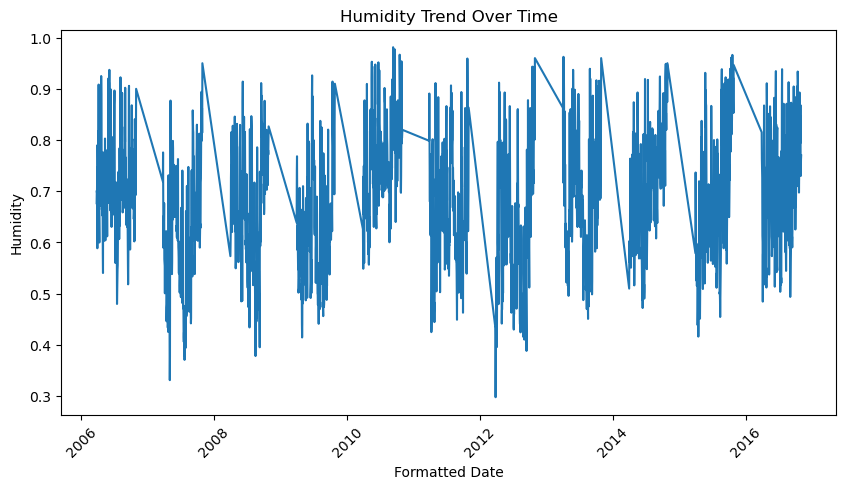

In [25]:
humidity_trend(df)

## Pattern Identification
In this step, we explore patterns and relationships between different weather variables.
Correlation analysis helps us understand how strongly different features are related to each other. A heatmap is used to visualize these relationships.

In [26]:
def identify_patterns(data):
    plt.figure(figsize=(6,6))
    sns.heatmap(data.corr(numeric_only=True), annot=True)
    plt.title("Correlation Between Features")
    plt.show()


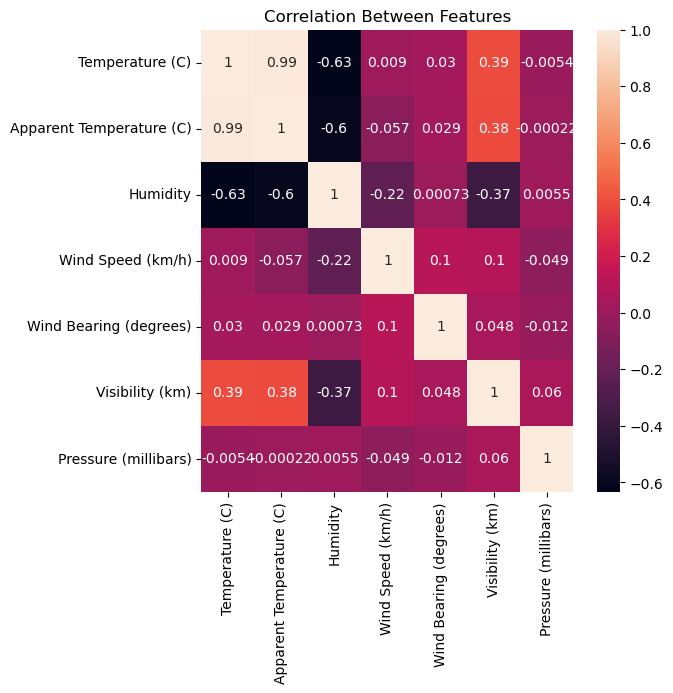

In [27]:
df = df.drop('Loud Cover', axis=1)
identify_patterns(df)

## Insights and Conclusion
- Temperature trends show seasonal variation
- Humidity fluctuates inversely with temperature
- Strong correlation between temperature and apparent temperature
- 'Loud Cover' column removed due to no variance